In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition
!ls
!pip install -r requirements.txt

/content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition
Data  FaceBook_solution_47441466  README.md  requirements.txt
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 129.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 141.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 135.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 1.6 MB/s eta 0:00:00

/content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/FaceBook_solution_47441466
config.ipynb   dataset.py	       modules.ipynb  predict.py   Saved_models
config.py      gcn_facebook_model.pth  modules.py     __pycache__  train.ipynb
dataset.ipynb  loss_plot.png	       predict.ipynb  README.md    train.py
Using device: cuda
Epoch 10, Train Loss: 0.6585, Val Loss: 0.6064
Epoch 20, Train Loss: 0.2989, Val Loss: 0.2964
Epoch 30, Train Loss: 0.2106, Val Loss: 0.2217
Epoch 40, Train Loss: 0.1769, Val Loss: 0.1954
Epoch 50, Train Loss: 0.1571, Val Loss: 0.1827
Test Accuracy: 0.9426


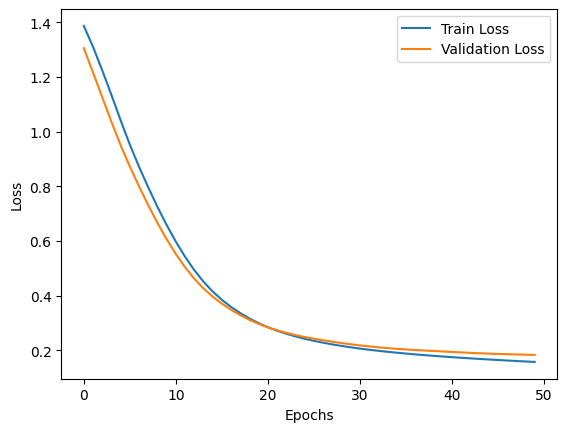

In [7]:
#Training, validation, testing and saving is done here
#imports from dataset.py and modules.py
#make sure to plot losses and metrics during training
%cd /content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/FaceBook_solution_47441466
!ls
import os
import torch
import torch.nn as nn
import torch.optim as optim
import time
from torch.utils.data import DataLoader
# from torchvision import transforms
import torch_geometric
from dataset import FacebookData
from train import Trainer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


save_directory = "/content/drive/MyDrive/COMP3710/A3/PatternAnalysis-2025/recognition/FaceBook_solution_47441466/Saved_models"
model_save_path = os.path.join(save_directory, "model.pth") # Added filename to the path
trainer = Trainer(data_path_prefix='/content/drive/MyDrive/COMP3710/A3/facebook')
##may also need to import loss functions and optimisers here if i decide to use pytorch built in ones
#standing on shoulders of giants makes it a lot easier. the less i code the better
#also set up command line args for certain things

trainer.train()

#save the model
torch.save(trainer.get_model().state_dict(), model_save_path) # Using the new file path